# Learning rasters in Python

In [12]:
import sys
import rasterio as rio
import geopandas as gpd
from requests import Request
from rasterio.profiles import DefaultGTiffProfile
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

## Example

Example from:
https://rasterio.readthedocs.io/en/latest/quickstart.html#reading-raster-data

In [9]:
x = np.linspace(-4.0, 4.0, 240)
y = np.linspace(-3.0, 3.0, 180)
X, Y = np.meshgrid(x, y)
Z1 = np.exp(-2 * np.log(2) * ((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 1 ** 2)
Z2 = np.exp(-3 * np.log(2) * ((X + 0.5) ** 2 + (Y + 0.5) ** 2) / 2.5 ** 2)
Z = 10.0 * (Z2 - Z1)

In [10]:
from rasterio.transform import Affine
res = (x[-1] - x[0]) / 240.0
transform = Affine.translation(x[0] - res / 2, y[0] - res / 2) * Affine.scale(res, res)
transform

Affine(0.03333333333333333, 0.0, -4.016666666666667,
       0.0, 0.03333333333333333, -3.0166666666666666)

In [13]:
new_dataset = rio.open(
    'new.tif',
    'w',
    driver='GTiff',
    height=Z.shape[0],
    width=Z.shape[1],
    count=1,
    dtype=Z.dtype,
    crs='+proj=latlong',
    transform=transform,
)

## More example
https://geoscripting-wur.github.io/PythonRaster/

In [14]:
import os
if not os.path.exists('data'): os.makedirs('data')
if not os.path.exists('output'): os.makedirs('output')

import tarfile
from urllib.request import urlretrieve

directory = './data/'
tarfilename = directory + "landsat.tar.gz"

if not os.path.exists(directory):
    os.makedirs(directory)

if not os.path.isfile(tarfilename):
    url = 'https://www.dropbox.com/s/zb7nrla6fqi1mq4/LC81980242014260-SC20150123044700.tar.gz?dl=1'
    urlretrieve(url, tarfilename)
    tar = tarfile.open(tarfilename)
    tar.extractall(path=directory)
    tar.close()

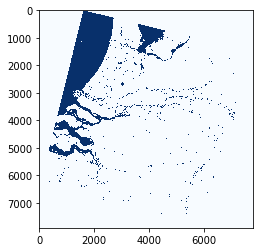

In [15]:
import numpy as np
import rasterio
from rasterio.plot import show

greenband = rasterio.open(directory + "LC81980242014260LGN00_sr_band4.tif")
mirband = rasterio.open(directory + "LC81980242014260LGN00_sr_band6.tif")

green = greenband.read(1).astype(float)
mir = mirband.read(1).astype(float)

np.seterr(divide='ignore', invalid='ignore')  # Allow division by zero
mndwi = np.empty(greenband.shape, dtype=rasterio.float32)  # Create empty matrix
check = np.logical_or(mir > 0.0, green > 0.0)  # Create check raster with True/False values
mndwi = np.where(check, (green - mir) / (green + mir), -999)  # Calculate MNDWI

water = np.where(mndwi > 0, 1, 0) # Set values above 0 as water and otherwise leave it at 0
show(water, cmap='Blues')

In [16]:
from owslib.wcs import WebCoverageService
wcs = WebCoverageService('http://geodata.nationaalgeoregister.nl/ahn2/wcs?service=WCS', version='1.0.0')
print(list(wcs.contents))

['ahn2_05m_int', 'ahn2_05m_non', 'ahn2_05m_ruw', 'ahn2_5m']


In [17]:
print([op.name for op in wcs.operations])

['GetCapabilities', 'DescribeCoverage', 'GetCoverage']


In [18]:
cvg = wcs.contents['ahn2_05m_ruw']
print(cvg.boundingBoxWGS84)
print(cvg.supportedCRS)
print(cvg.supportedFormats)

(3.24665027182318, 50.4823238596714, 7.66798959275226, 53.5334936736242)
[urn:ogc:def:crs:EPSG::28992, urn:ogc:def:crs:EPSG::28992]
['GEOTIFF_BYTE', 'GEOTIFF_INT16', 'GEOTIFF_RGB', 'GEOTIFF_FLOAT32']


In [19]:
x, y = 174100, 444100
bbox = (x-500, y-500, x+500, y+500)
response = wcs.getCoverage(identifier='ahn2_05m_ruw', bbox=bbox, format='GEOTIFF_FLOAT32',
                           crs='urn:ogc:def:crs:EPSG::28992', resx=0.5, resy=0.5)
with open('./data/AHN2_05m_DSM.tif', 'wb') as file:
    file.write(response.read())

response = wcs.getCoverage(identifier='ahn2_05m_int', bbox=bbox, format='GEOTIFF_FLOAT32',
                           crs='urn:ogc:def:crs:EPSG::28992', resx=0.5, resy=0.5)
with open('./data/AHN2_05m_DTM.tif', 'wb') as file:
    file.write(response.read())

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 2000, 'height': 2000, 'count': 1, 'crs': CRS.from_epsg(28992), 'transform': Affine(0.5, 0.0, 173600.0,
       0.0, -0.5, 444600.0)}
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 2000, 'height': 2000, 'count': 1, 'crs': CRS.from_epsg(28992), 'transform': Affine(0.5, 0.0, 173600.0,
       0.0, -0.5, 444600.0)}


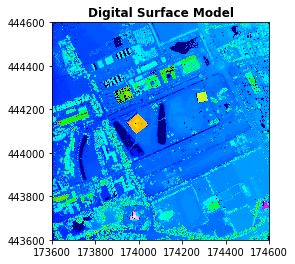

In [20]:
DSM = rasterio.open("./data/AHN2_05m_DSM.tif", driver="GTiff")
DTM = rasterio.open("./data/AHN2_05m_DTM.tif", driver="GTiff")
print(DSM.meta)
print(DTM.meta)
show(DSM, title='Digital Surface Model', cmap='gist_ncar')

In [21]:
print(type(DSM))
print(type(DSM.read(1)))
print(DSM.read(1))

<class 'rasterio.io.DatasetReader'>
<class 'numpy.ndarray'>
[[ 9.724  9.685  9.692 ... 15.521 15.575 15.62 ]
 [ 9.707  9.696  9.697 ... 15.699 15.759 15.784]
 [ 9.7    9.674  9.675 ... 15.956 15.946 15.971]
 ...
 [ 8.238  8.235  8.218 ...  0.     0.     0.   ]
 [ 8.221  8.202  8.206 ...  0.     0.     0.   ]
 [ 8.204  8.183  8.207 ...  0.     0.     0.   ]]


### Processing the data

In [22]:
CHM = DSM.read() - DTM.read()
print(type(CHM))

kwargs = DSM.meta # Copy metadata of rasterio.io.DatasetReader
with rasterio.open('./data/AHN2_05m_CHM.tif', 'w', **kwargs) as file:
    file.write(CHM.astype(rasterio.float32))

<class 'numpy.ndarray'>


In [27]:
import geopandas as gpd
from requests import Request
# extract only buildings on and around WUR campus
url = 'https://geodata.nationaalgeoregister.nl/bag/wfs'
layer = 'bag:pand' # see wfs.contents
bb = ','.join(map(str, bbox)) # string of bbox needed for the request url
# Specify the parameters for fetching the data
params = dict(service='WFS', version="2.0.0", request='GetFeature',
      typeName=layer, outputFormat='text/xml; subtype=gml/3.2',
      srsname='urn:ogc:def:crs:EPSG::28992', bbox=bb)
# Parse the URL with parameters
q = Request('GET', url, params=params).prepare().url
# Read data from URL
#BuildingsGDF = gpd.read_file()

### Write some data

In [29]:
import affine
kwargs = {'driver': 'GTiff',
          'dtype': 'float32',
          'nodata': None,
          'width': 2000,
          'height': 2000,
          'count': 1,
          'crs': rasterio.crs.CRS({'init': 'epsg:28992'}),
          'transform': affine.Affine(0.5, 0.0, 173600.0, 0.0, -0.5, 444600.0)}
# kwargs = DSM.meta # Metadata can be copied from existing file if needed
with rasterio.open('./data/AHN2_05m_CHM.tif', 'w', **kwargs) as file:
    file.write(CHM.astype(rasterio.float32))

In [30]:
CHM = rasterio.open("./data/AHN2_05m_CHM.tif")
print(CHM.meta)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 2000, 'height': 2000, 'count': 1, 'crs': CRS.from_epsg(28992), 'transform': Affine(0.5, 0.0, 173600.0,
       0.0, -0.5, 444600.0)}


### Viz

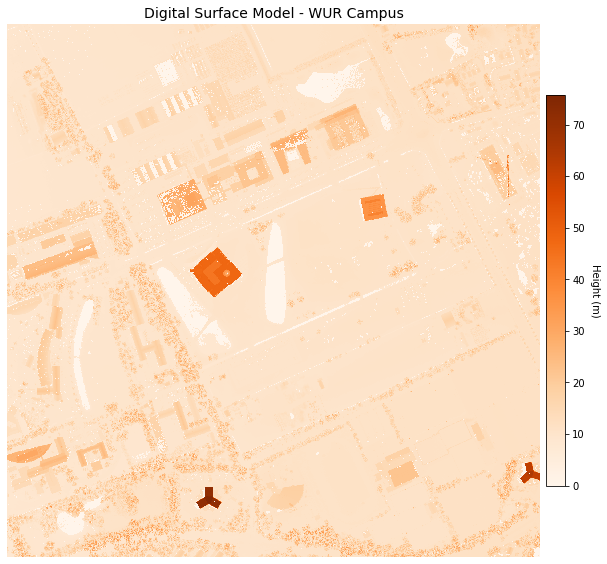

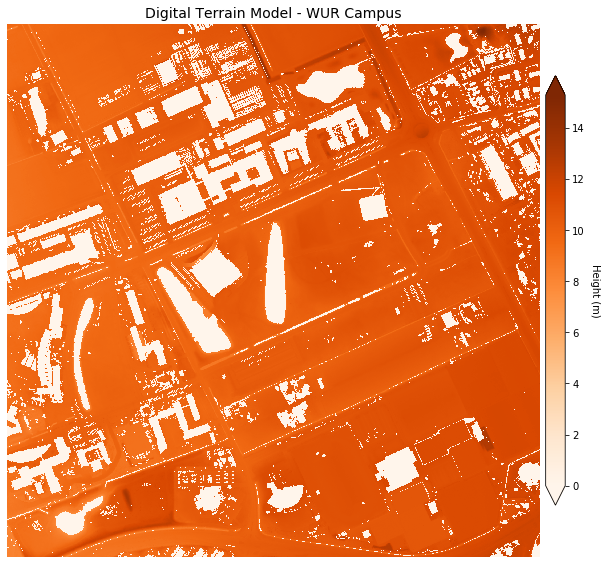

In [32]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,10))
dsmplot = ax.imshow(DSM.read(1), cmap='Oranges', extent=bbox)
ax.set_title("Digital Surface Model - WUR Campus", fontsize=14)
cbar = fig.colorbar(dsmplot, fraction=0.035, pad=0.01)
cbar.ax.get_yaxis().labelpad = 15
cbar.ax.set_ylabel('Height (m)', rotation=270)
ax.set_axis_off()
plt.show()

fig, ax = plt.subplots(figsize=(10,10))
dtmplot = ax.imshow(DTM.read(1), cmap='Oranges', extent=bbox)
ax.set_title("Digital Terrain Model - WUR Campus", fontsize=14)
cbar = fig.colorbar(dtmplot, fraction=0.035, pad=0.01, extend='both')
cbar.ax.get_yaxis().labelpad = 15
cbar.ax.set_ylabel('Height (m)', rotation=270)
ax.set_axis_off()
plt.show()

## My data

In [49]:
r = rasterio.open("rThK.tif", "r",driver='GTiff')

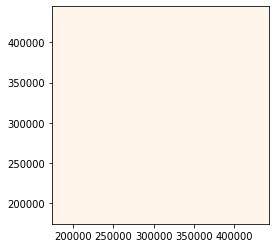

In [47]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = plt.imshow(r.read(1), cmap='Oranges', extent=bbox)
#ax.set_title("ThK", fontsize=14)
plt.show()


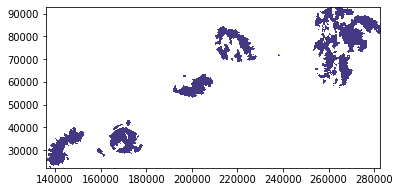

In [51]:
from rasterio.plot import show
show(r)

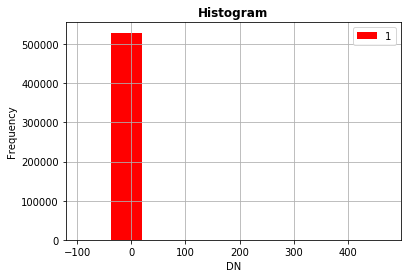

In [52]:
from rasterio.plot import show_hist
show_hist(r)